# 52 — SimCLR on CIFAR-10

The [previous notebook](./51_contrastive_learning_and_infonce.ipynb) studied InfoNCE using embedding vectors directly. We will now train an image encoder with a small **SimCLR-style** pipeline:

1. draw two independent augmented views of every image;
2. encode each view into a representation $h$;
3. map $h$ through a projection head to $z$;
4. apply InfoNCE to the projected embeddings;
5. discard the projection head and evaluate the encoder representation.

We will compare three downstream conditions under the same labeled-data budget:

- a frozen randomly initialized encoder;
- a frozen SimCLR-pretrained encoder;
- the SimCLR encoder fine-tuned using class labels.

This remains a small educational experiment. Modern SimCLR systems use larger encoders, more data, longer training, and carefully tuned augmentations.

In [1]:
from copy import deepcopy
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.datasets import CIFAR10

from cs231n_practice.classifiers.self_supervised import SmallEncoder
from cs231n_practice.self_supervised import (
    extract_features,
    freeze_encoder,
    info_nce_loss,
    pairwise_cosine_similarity,
    positive_pair_indices,
)

SEED = 17
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

print(f"Using {DEVICE}")

Using mps


## 1. Controlled data subsets

Class labels are deliberately excluded from contrastive pretraining. They appear only in the downstream probe and fine-tuning stages.

- 6,000 training images: unlabeled SimCLR pretraining
- 1,000 disjoint training images: labeled downstream training
- 2,000 test images: held-out evaluation

The small labeled subset makes representation quality matter more than it would if we fine-tuned on all 50,000 labels.

In [2]:
train_dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
test_dataset = CIFAR10(root=DATA_DIR, train=False, download=True)

all_train_images = torch.from_numpy(train_dataset.data).permute(0, 3, 1, 2).float() / 255.0
all_train_labels = torch.tensor(train_dataset.targets)
all_test_images = torch.from_numpy(test_dataset.data).permute(0, 3, 1, 2).float() / 255.0
all_test_labels = torch.tensor(test_dataset.targets)

generator = torch.Generator().manual_seed(SEED)
train_order = torch.randperm(len(all_train_images), generator=generator)
test_order = torch.randperm(len(all_test_images), generator=generator)

pretrain_images = all_train_images[train_order[:6000]]
probe_images = all_train_images[train_order[6000:7000]]
probe_labels = all_train_labels[train_order[6000:7000]]
evaluation_images = all_test_images[test_order[:2000]]
evaluation_labels = all_test_labels[test_order[:2000]]

assert pretrain_images.shape == (6000, 3, 32, 32)
assert probe_images.shape == (1000, 3, 32, 32)
assert evaluation_images.shape == (2000, 3, 32, 32)

## 2. Two independent augmented views

SimCLR relies heavily on augmentation design. Our compact pipeline uses:

- random resized crops to change framing and scale;
- horizontal flips to change orientation without usually changing class;
- color jitter and occasional grayscale conversion to discourage reliance on exact color.

The two views must be sampled **independently**. Applying one random transformation and copying its result would create identical positives and make the matching task too easy.

The transformations operate on `[0, 1]` images. We normalize the results afterward using CIFAR-10 channel statistics before passing them to the encoder.

### Exercise 1 — Generate two views

Apply `transform` independently twice to every image, stack each group, and return two NCHW batches.

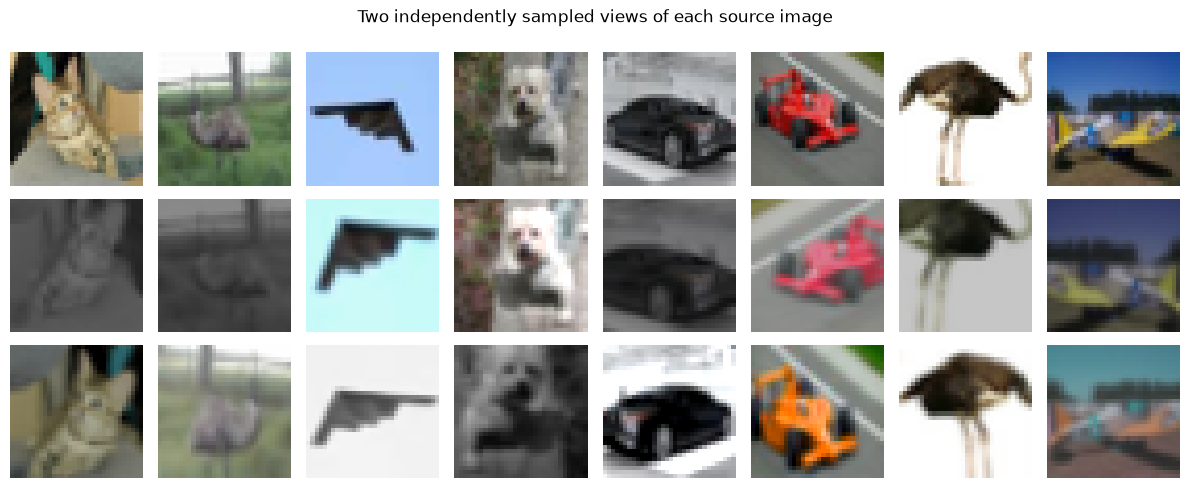

In [4]:
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        32,
        scale=(0.55, 1.0),
        ratio=(0.8, 1.25),
        antialias=True,
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.4,
            contrast=0.4,
            saturation=0.4,
            hue=0.1,
        )
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
])

CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
CIFAR_STD = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)


def normalize_images(images):
    return (images - CIFAR_MEAN.to(images.device)) / CIFAR_STD.to(images.device)


def make_contrastive_views(images, transform):
    # call transform independently for every image in view A and view B.
    view_a = torch.stack([
        transform(image)
        for image in images
    ])

    view_b = torch.stack([
        transform(image)
        for image in images
    ])
    return view_a, view_b


torch.manual_seed(SEED)
sample_images = pretrain_images[:8]
sample_view_a, sample_view_b = make_contrastive_views(
    sample_images,
    contrastive_transform,
)
assert sample_view_a.shape == sample_images.shape
assert sample_view_b.shape == sample_images.shape

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for column in range(8):
    for row, batch in enumerate((sample_images, sample_view_a, sample_view_b)):
        axes[row, column].imshow(batch[column].permute(1, 2, 0).clamp(0, 1))
        axes[row, column].axis("off")
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("view A")
axes[2, 0].set_ylabel("view B")
plt.suptitle("Two independently sampled views of each source image")
plt.tight_layout()
plt.show()

### Why these augmentations define what the model learns

Contrastive training encourages the representation to retain information shared by both views and ignore information that varies between them. Color jitter therefore teaches some color invariance; cropping teaches robustness to framing. This is useful only when those changes preserve the intended semantics.

An augmentation can be harmful when it changes the downstream answer. For example, horizontal flipping is unsuitable if the target distinguishes left-facing from right-facing objects. Augmentations are therefore part of the learning objective, not merely cosmetic preprocessing.

## 3. Encoder, representation, and projection head

SimCLR distinguishes two vectors:

$$
h = f_\theta(x),
\qquad
z = g_\phi(h).
$$

- $h$ is the encoder representation used by downstream tasks.
- $z$ is the projection used only by the contrastive loss.

The projection head allows the loss to shape a task-specific contrastive space without requiring the retained representation $h$ to discard every detail. After pretraining, $g_\phi$ is removed.

### Exercise 2 — Complete the SimCLR forward pass

Return both `representations` and `projections`. Do not normalize them here because the reusable InfoNCE function performs normalization internally.

In [7]:
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=64, projection_dim=32):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim),
        )

    def forward(self, representations):
        return self.network(representations)


class SmallSimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = SmallEncoder(feature_dim=64)
        self.projector = ProjectionHead(64, 64, 32)

    def forward(self, images):
        # encode images into h and project h into z.
        # Encode each image into its reusable representation h.
        representations = self.encoder(images)

        # Map h into the space used by the contrastive loss.
        projections = self.projector(representations)
        return representations, projections


torch.manual_seed(SEED + 1)
simclr_model = SmallSimCLR()
# Preserve exactly the initial encoder for the random-feature baseline.
initial_encoder_state = deepcopy(simclr_model.encoder.state_dict())

sample_h, sample_z = simclr_model(normalize_images(sample_view_a))
assert sample_h.shape == (8, 64)
assert sample_z.shape == (8, 32)

## 4. One contrastive training step

For a source minibatch of size $N$:

1. produce `view_a` and `view_b`;
2. obtain projected embeddings `z_a` and `z_b`;
3. concatenate them in `[view_a; view_b]` order;
4. calculate symmetric InfoNCE over the resulting $2N$ embeddings.

Only images enter this step—there are no CIFAR-10 labels.

### Exercise 3 — Calculate the minibatch loss

Complete `contrastive_batch_loss`. Remember to normalize input pixels, but let `info_nce_loss` normalize the projection vectors.

In [ ]:
def contrastive_batch_loss(model, images, transform, temperature):
    view_a, view_b = make_contrastive_views(images, transform)
    view_a = normalize_images(view_a).to(DEVICE)
    view_b = normalize_images(view_b).to(DEVICE)

    # obtain both projection batches.
    _, projections_a = model(view_a)
    _, projections_b = model(view_b)
    # concatenate in [view A; view B] order and calculate InfoNCE.
    projections = torch.cat(
        (projections_a, projections_b),
        dim=0,
    )
    loss = info_nce_loss(
        projections,
        temperature=temperature,
    )
    return loss, projections


simclr_model = simclr_model.to(DEVICE)
sample_loss, sample_projections = contrastive_batch_loss(
    simclr_model,
    pretrain_images[:16],
    contrastive_transform,
    temperature=0.2,
)
assert sample_loss.ndim == 0
assert sample_projections.shape == (32, 32)
assert torch.isfinite(sample_loss)

## 5. Contrastive pretraining

Alongside loss, we record:

- mean positive similarity;
- mean negative similarity over all non-self, non-positive entries.

Useful learning usually raises positive similarity relative to negative similarity. The absolute values need not approach 1 and $-1$, respectively.

In [14]:
@torch.no_grad()
def contrastive_similarity_metrics(projections):
    similarities = pairwise_cosine_similarity(projections)
    number_of_embeddings = len(projections)
    rows = torch.arange(number_of_embeddings, device=projections.device)
    positives = positive_pair_indices(
        number_of_embeddings,
        device=projections.device,
    )
    excluded = torch.eye(
        number_of_embeddings,
        dtype=torch.bool,
        device=projections.device,
    )
    excluded[rows, positives] = True
    positive_similarity = similarities[rows, positives].mean()
    negative_similarity = similarities[~excluded].mean()
    return float(positive_similarity), float(negative_similarity)


def pretrain_simclr(
    model,
    images,
    transform,
    epochs=8,
    batch_size=128,
    learning_rate=2e-3,
    temperature=0.2,
):
    loader = DataLoader(
        TensorDataset(images),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"loss": [], "positive_similarity": [], "negative_similarity": []}
    model.to(DEVICE)

    for epoch in range(epochs):
        model.train()
        loss_sum = positive_sum = negative_sum = 0.0
        example_count = 0
        start_time = time.perf_counter()

        for (image_batch,) in loader:
            loss, projections = contrastive_batch_loss(
                model,
                image_batch,
                transform,
                temperature,
            )
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            positive, negative = contrastive_similarity_metrics(projections.detach())
            batch_count = len(image_batch)
            loss_sum += loss.item() * batch_count
            positive_sum += positive * batch_count
            negative_sum += negative * batch_count
            example_count += batch_count

        history["loss"].append(loss_sum / example_count)
        history["positive_similarity"].append(positive_sum / example_count)
        history["negative_similarity"].append(negative_sum / example_count)
        elapsed = time.perf_counter() - start_time
        print(
            f"epoch {epoch + 1:2d}: loss={history['loss'][-1]:.3f}, "
            f"positive={history['positive_similarity'][-1]:.3f}, "
            f"negative={history['negative_similarity'][-1]:.3f}, "
            f"time={elapsed:.1f}s"
        )

    return history


torch.manual_seed(SEED + 2)
pretrain_history = pretrain_simclr(
    simclr_model,
    pretrain_images,
    contrastive_transform,
)

epoch  1: loss=4.848, positive=0.828, negative=0.498, time=5.0s
epoch  2: loss=4.166, positive=0.766, negative=0.178, time=4.2s
epoch  3: loss=3.668, positive=0.769, negative=0.072, time=4.1s
epoch  4: loss=3.405, positive=0.786, negative=0.070, time=4.3s
epoch  5: loss=3.262, positive=0.789, negative=0.051, time=4.0s
epoch  6: loss=3.167, positive=0.788, negative=0.039, time=4.0s
epoch  7: loss=3.094, positive=0.794, negative=0.047, time=4.0s
epoch  8: loss=2.983, positive=0.796, negative=0.040, time=4.1s


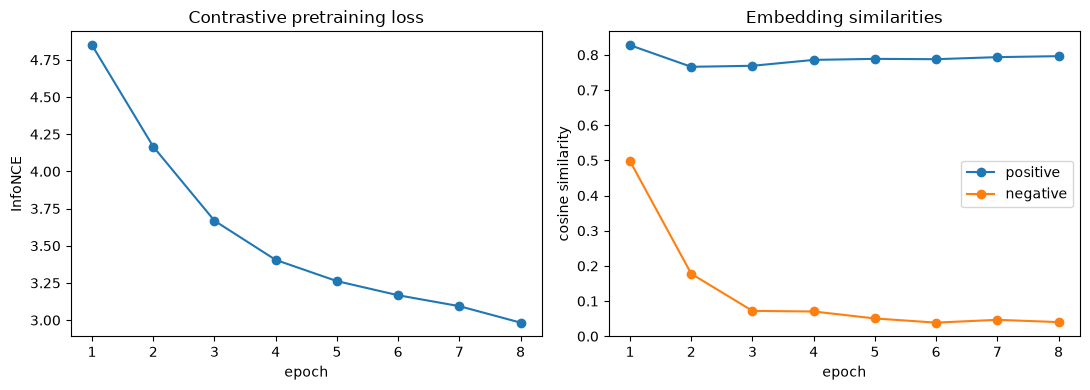

In [15]:
epochs = np.arange(1, len(pretrain_history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, pretrain_history["loss"], marker="o")
axes[0].set(title="Contrastive pretraining loss", xlabel="epoch", ylabel="InfoNCE")
axes[1].plot(epochs, pretrain_history["positive_similarity"], marker="o", label="positive")
axes[1].plot(epochs, pretrain_history["negative_similarity"], marker="o", label="negative")
axes[1].set(title="Embedding similarities", xlabel="epoch", ylabel="cosine similarity")
axes[1].legend()
plt.tight_layout()
plt.show()

### Exercise 4 — Read the pretraining curves

1. Did the InfoNCE loss decrease?
2. Did a gap develop between positive and negative similarities?
3. Why does this still not tell us whether the encoder learned CIFAR-10 class information?

**Your answers:**

1. Yes, at all of 8 epochs 
2. Yes. The gap increased most strongly during the first three epochs, mainly because negative similarity dropped. It continued improving more slowly afterward.
3. CIFAR-10 labels were not used, and InfoNCE measures positive-pair matching rather than class recognition. The learned features may contain class information, but that must be tested separately with a linear probe or another downstream evaluation.

## 6. Frozen linear-probe comparison

We now discard the projection head and compare two frozen encoders:

- `random_encoder` uses the exact encoder weights saved before pretraining;
- `pretrained_encoder` uses the weights learned through InfoNCE.

The same normalized images, 1,000 labels, linear-head architecture, optimizer, and epoch budget are used in both conditions. Because encoders are frozen, differences are attributable to their existing representations rather than supervised adaptation.

In [16]:
def train_linear_probe(
    train_features,
    train_labels,
    evaluation_features,
    evaluation_labels,
    epochs=50,
    learning_rate=5e-2,
):
    torch.manual_seed(SEED + 10)
    head = nn.Linear(train_features.shape[1], len(CLASS_NAMES)).to(DEVICE)
    optimizer = torch.optim.Adam(head.parameters(), lr=learning_rate)
    loader = DataLoader(
        TensorDataset(train_features, train_labels),
        batch_size=128,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    history = {"train_accuracy": [], "evaluation_accuracy": []}

    for _ in range(epochs):
        head.train()
        for feature_batch, label_batch in loader:
            logits = head(feature_batch.to(DEVICE))
            loss = nn.functional.cross_entropy(logits, label_batch.to(DEVICE))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        head.eval()
        with torch.no_grad():
            train_predictions = head(train_features.to(DEVICE)).argmax(1).cpu()
            evaluation_predictions = head(evaluation_features.to(DEVICE)).argmax(1).cpu()
        history["train_accuracy"].append(
            float((train_predictions == train_labels).float().mean())
        )
        history["evaluation_accuracy"].append(
            float((evaluation_predictions == evaluation_labels).float().mean())
        )
    return head.cpu(), history


random_encoder = SmallEncoder(feature_dim=64)
random_encoder.load_state_dict(initial_encoder_state)
random_encoder = freeze_encoder(random_encoder.to(DEVICE))
pretrained_encoder = freeze_encoder(simclr_model.encoder)

normalized_probe_images = normalize_images(probe_images)
normalized_evaluation_images = normalize_images(evaluation_images)
probe_results = {}

for name, encoder in {
    "random frozen": random_encoder,
    "SimCLR frozen": pretrained_encoder,
}.items():
    train_features = extract_features(encoder, normalized_probe_images)
    test_features = extract_features(encoder, normalized_evaluation_images)
    head, history = train_linear_probe(
        train_features,
        probe_labels,
        test_features,
        evaluation_labels,
    )
    probe_results[name] = {
        "head": head,
        "history": history,
        "train_features": train_features,
        "test_features": test_features,
    }
    print(
        f"{name:14s}: train={history['train_accuracy'][-1]:.3f}, "
        f"evaluation={history['evaluation_accuracy'][-1]:.3f}"
    )

random frozen : train=0.336, evaluation=0.304
SimCLR frozen : train=0.481, evaluation=0.396


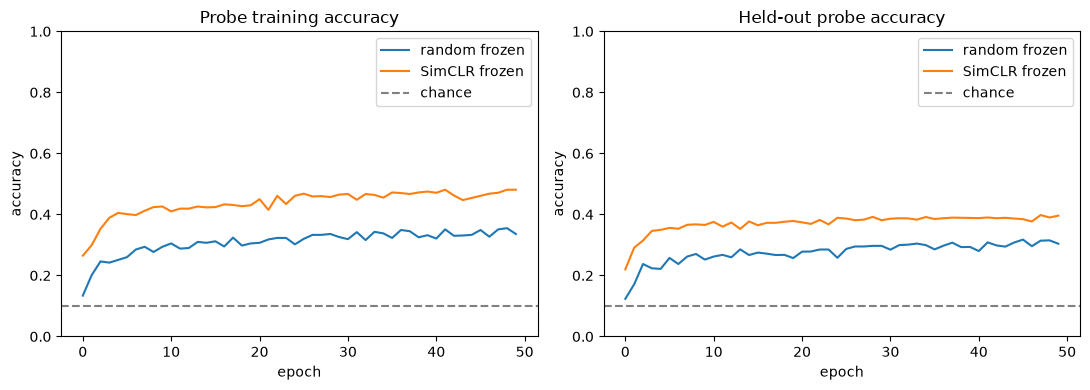

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, result in probe_results.items():
    axes[0].plot(result["history"]["train_accuracy"], label=name)
    axes[1].plot(result["history"]["evaluation_accuracy"], label=name)
for axis, title in zip(axes, ("Probe training accuracy", "Held-out probe accuracy")):
    axis.set(title=title, xlabel="epoch", ylabel="accuracy", ylim=(0, 1))
    axis.axhline(0.1, color="gray", linestyle="--", label="chance")
    axis.legend()
plt.tight_layout()
plt.show()

### Exercise 5 — Interpret the frozen comparison

1. Which encoder gives the stronger held-out linear probe?
2. What does improvement over the identical random encoder demonstrate?
3. Why does a weak or negative result in this small run not disprove SimCLR?

**Your answers:**

1. frozen SimCLR is stronger
2. encoder learnt some useful details about class labels during contrastive pretraining
3. limited data

### Why is this random baseline higher than in [Notebook 50](./50_self_supervised_learning_and_pretext_tasks.ipynb)?

[Notebook 50](./50_self_supervised_learning_and_pretext_tasks.ipynb) obtained about 24% accuracy from a random encoder, while this notebook obtains about 30%. The encoder architecture and initialization are effectively the same, but the evaluation protocols are not:

- [Notebook 50](./50_self_supervised_learning_and_pretext_tasks.ipynb) passes raw `[0, 1]` images to the encoder; this notebook applies channel-wise CIFAR-10 normalization.
- The notebooks use different randomly selected groups of 1,000 labeled images.
- This probe trains for 50 rather than 40 epochs and explicitly fixes the linear-head seed.

A controlled check with the same random encoder, probe seed, evaluation set, and 50 epochs produced 23.5% for Notebook 50's subset with raw inputs, 26.9% for this notebook's subset with raw inputs, and 30.4% after this notebook's normalization. Thus, both the sampled labeled subset and preprocessing explain most of the difference.

A random CNN can exceed 10% chance accuracy because random convolutions still preserve structured color, edge, texture, and local-pattern information that a trained linear head can combine. The reliable conclusions are the **within-notebook** comparisons, where the random and pretrained encoders share the same data, preprocessing, and probe protocol.

## 7. Fine-tuning with the same labeled subset

A linear probe asks what information is already linearly accessible. **Fine-tuning** asks how well the pretrained encoder can adapt when labels are allowed to update all its weights.

Fine-tuning often improves accuracy, but it is no longer a pure representation measurement: supervised labels now change the encoder. We start from the pretrained weights and train an attached linear classifier end to end.

In [20]:
class FineTunedClassifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder.feature_dim, len(CLASS_NAMES))

    def forward(self, images):
        return self.classifier(self.encoder(images))


def train_fine_tuned_classifier(
    model,
    images,
    labels,
    evaluation_images,
    evaluation_labels,
    epochs=40,
    learning_rate=1e-3,
):
    loader = DataLoader(
        TensorDataset(images, labels),
        batch_size=128,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train_accuracy": [], "evaluation_accuracy": []}
    model.to(DEVICE)

    for _ in range(epochs):
        model.train()
        for image_batch, label_batch in loader:
            logits = model(image_batch.to(DEVICE))
            loss = nn.functional.cross_entropy(logits, label_batch.to(DEVICE))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            train_predictions = model(images.to(DEVICE)).argmax(1).cpu()
            evaluation_predictions = model(evaluation_images.to(DEVICE)).argmax(1).cpu()
        history["train_accuracy"].append(
            float((train_predictions == labels).float().mean())
        )
        history["evaluation_accuracy"].append(
            float((evaluation_predictions == evaluation_labels).float().mean())
        )
    return history


# deepcopy creates trainable parameters independent of the frozen probe encoder.
fine_tune_encoder = deepcopy(simclr_model.encoder).cpu()
for parameter in fine_tune_encoder.parameters():
    parameter.requires_grad_(True)
fine_tuned_model = FineTunedClassifier(fine_tune_encoder)

fine_tune_history = train_fine_tuned_classifier(
    fine_tuned_model,
    normalized_probe_images,
    probe_labels,
    normalized_evaluation_images,
    evaluation_labels,
)
print(
    f"fine-tuned: train={fine_tune_history['train_accuracy'][-1]:.3f}, "
    f"evaluation={fine_tune_history['evaluation_accuracy'][-1]:.3f}"
)

fine-tuned: train=0.486, evaluation=0.388


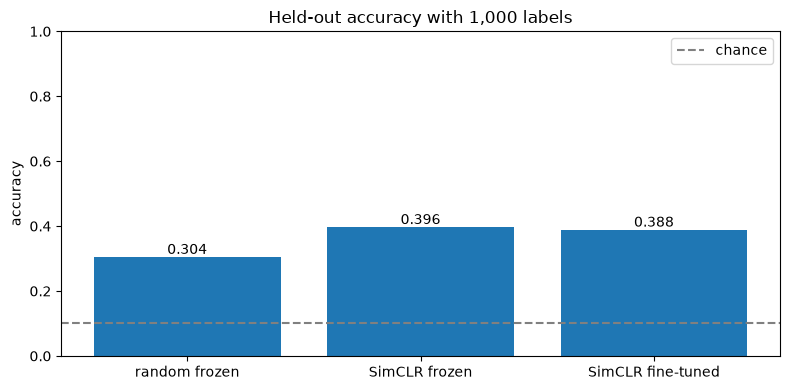

In [21]:
final_results = {
    "random frozen": probe_results["random frozen"]["history"]["evaluation_accuracy"][-1],
    "SimCLR frozen": probe_results["SimCLR frozen"]["history"]["evaluation_accuracy"][-1],
    "SimCLR fine-tuned": fine_tune_history["evaluation_accuracy"][-1],
}

fig, axis = plt.subplots(figsize=(8, 4))
bars = axis.bar(final_results.keys(), final_results.values())
axis.set(title="Held-out accuracy with 1,000 labels", ylabel="accuracy", ylim=(0, 1))
axis.axhline(0.1, color="gray", linestyle="--", label="chance")
axis.bar_label(bars, fmt="%.3f")
axis.legend()
plt.tight_layout()
plt.show()

### Exercise 6 — Linear probing versus fine-tuning

1. Did fine-tuning outperform the frozen SimCLR probe?
2. Why can fine-tuning improve the result even when both methods begin with the same encoder?
3. Why should frozen-probe accuracy still be reported separately?

**Your answers:**

1. No. Fine-tuning reached 38.8%, slightly below the frozen probe’s 39.6%.
2. Fine-tuning updates the encoder as well as the classifier, allowing its features to adapt to class labels, although this can overfit limited data.
3. The frozen probe isolates the quality of the representation learned through contrastive pretraining, without supervised modification of the encoder.

## 8. Controlled extensions

The main run fixes augmentation strength, temperature, batch size, and training length. To study one factor, change only that factor while keeping the seed, subsets, model, and evaluation protocol fixed.

Useful follow-up experiments include:

- **weaker augmentation:** crop and flip without color jitter or grayscale;
- **temperature:** compare values such as `0.1`, `0.2`, and `0.5`;
- **batch size:** compare the number of in-batch negatives while noting memory cost;
- **training length:** test whether representation quality continues improving after the short run.

Do not choose the best setting using test accuracy. A rigorous experiment would introduce a validation subset for model selection and reserve the test set for the final evaluation. Also remember that contrastive losses are not directly comparable across different batch sizes because the number of candidates changes.

## Reflection

1. How does SimCLR create supervision without CIFAR-10 labels?
2. Why must the two augmented views be sampled independently?
3. What invariances do crop, color jitter, and grayscale encourage?
4. What is the difference between encoder representation $h$ and projection $z$?
5. Why is the projection head discarded after pretraining?
6. Why concatenate projections in `[view A; view B]` order?
7. What does a growing positive-versus-negative similarity gap suggest?
8. What does the random frozen baseline control for?
9. How does a frozen linear probe differ from fine-tuning?
10. Why should augmentation, temperature, batch size, and training duration be varied one at a time?

### Answers

1. SimCLR creates two augmented views of each source image. Views from the same source are positive pairs, while views from other sources serve as negatives.
2. Independent sampling prevents one transformed image from simply being copied twice and exposes the encoder to different variations of the same source.
3. Cropping encourages robustness to framing, position, and scale. Color jitter discourages reliance on exact colors, while grayscale encourages the model to retain useful shape and texture information when color is absent.
4. $h$ is the encoder’s reusable representation. $z$ is produced from $h$ by the projection head and is used for the contrastive loss.
5. The projection head creates a space specialized for satisfying the contrastive objective. After pretraining, it is discarded and the more general encoder representation $h$ is used downstream.
6. This ordering makes the positive mapping predictable: row $i$ in view A pairs with row $i+N$ in view B, and vice versa.
7. A growing gap suggests that the model is learning to align positive views while distinguishing them from other source images.
8. It helps to isolate the improvement caused by contrastive pretraining.
9. A frozen linear probe trains only a new linear classifier while leaving the encoder unchanged. Fine-tuning allows class labels to update both the classifier and encoder.
10. Varying one factor at a time makes it possible to attribute a result change to that factor rather than to several simultaneous changes.